## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import random
import math
import time
import logging

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from solution import solution

logging.getLogger('tensorflow').setLevel(logging.ERROR)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ── Global style – konsisten dengan visualisasi MIMO ────────────────────
_C = dict(
    train   = '#A0AEC0',
    val_act = '#63B3ED',
    act     = '#378ADD',
    val_p   = '#EF9F27',
    test_p  = '#E24B4A',
    split   = '#1D9E75',
    loss_tr = '#378ADD',
    loss_va = '#EF9F27',
    hho_cv  = '#7F77DD',
)
HORIZON_COLORS = ['#1D9E75', '#63B3ED', '#EF9F27', '#E24B4A', '#7F77DD']

plt.rcParams.update({
    'figure.facecolor' : '#FFFFFF',
    'axes.facecolor'   : '#FFFFFF',
    'axes.edgecolor'   : '#E2E8F0',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : True,
    'grid.color'       : '#E2E8F0',
    'grid.linewidth'   : 0.6,
    'grid.alpha'       : 1.0,
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'font.family'      : 'sans-serif',
    'font.size'        : 10,
    'text.color'       : '#1A202C',
})

def _spine(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def _fmt_usd(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

def _fmt_date(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

def _subtitle(ax, txt):
    ax.annotate(txt, xy=(0, 1.04), xycoords='axes fraction',
                fontsize=8.5, color='#718096')


## 2. LOAD & PREPROCESS

In [ ]:
df = pd.read_csv('nvda_gabungan.csv')

if df.isnull().values.any():
    df = df.dropna()
    print("Dropped rows with missing values.")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()

TARGET_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
N_FEATURES  = len(TARGET_COLS)
data        = df[TARGET_COLS].copy()

print(f"Data shape : {data.shape}")
print(f"Periode    : {data.index[0].date()} -> {data.index[-1].date()}")


## 3. WALK-FORWARD SPLIT (70 / 15 / 15)

> Split dilakukan **sebelum** scaling, identik dengan `01_lstm_mimo_baseline.ipynb`,
> agar perbandingan kedua model adil (BAB 3.6.2).

In [ ]:
test_size = int(len(data) * 0.15)
val_size  = int(len(data) * 0.15)

test_df  = data.iloc[-test_size:]
val_df   = data.iloc[-(test_size + val_size):-test_size]
train_df = data.iloc[:-(test_size + val_size)]

print("=" * 65)
print("  WALK-FORWARD SPLIT (70/15/15) - LSTM MIMO + HHO")
print("=" * 65)
for label, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {label:<6} | {d.index[0].date()} -> {d.index[-1].date()} "
          f"| {len(d):>4} baris | Close min={d['Close'].min():.2f}  max={d['Close'].max():.2f}")


## 4. NORMALISASI (Min-Max per Fitur, fit hanya pada Train)

Sesuai BAB 3.4.2, identik dengan baseline: seluruh variabel input (Open, High, Low,
Close, Volume) dinormalisasi langsung dengan Min-Max ke rentang [0, 1]. Scaler di-fit
**hanya** pada data training untuk menghindari data leakage.

> Catatan revisi: versi sebelumnya memakai normalisasi berbasis percentage change
> (return) dengan alasan menghindari *price jump* ekstrem. Pendekatan itu dibuang
> karena membuat preprocessing HHO tidak identik dengan baseline (melanggar syarat
> fair comparison BAB 3.6.2), dan compounding error saat inverse-transform return ke
> harga absolut justru membesarkan RMSE di skala harga meski val_loss di skala return
> terlihat rendah.

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

close_idx = TARGET_COLS.index('Close')
print("Close price - scaler range (fit pada train):")
print(f"  min : {scaler.data_min_[close_idx]:.4f}")
print(f"  max : {scaler.data_max_[close_idx]:.4f}")


## 5. PEMBUATAN DATASET MIMO

In [ ]:
n_input    = 60   # window size (fixed, sesuai keputusan project)
n_forecast = 5    # forecast horizon (fixed)

def create_dataset(dataset, n_input, n_forecast):
    """
    Strategi MIMO: X = window n_input hari x 5 fitur, y = Close n_forecast hari ke depan.
    """
    X, Y = [], []
    for i in range(n_input, len(dataset) - n_forecast):
        X.append(dataset[i - n_input:i, :])
        Y.append(dataset[i:i + n_forecast, close_idx])
    return np.array(X), np.array(Y)

X_train, y_train = create_dataset(train_scaled, n_input, n_forecast)
X_val,   y_val   = create_dataset(val_scaled,   n_input, n_forecast)
X_test,  y_test  = create_dataset(test_scaled,  n_input, n_forecast)

print(f"X_train : {X_train.shape}  -> (samples, n_input={n_input}, N_FEATURES={N_FEATURES})")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  -> (samples, n_forecast={n_forecast}) [skala 0-1]")


## 6. GROUND TRUTH HARGA ABSOLUT (Inverse Transform Target)

In [ ]:
def inverse_close(scaled_values):
    """Inverse-transform kolom Close dari skala [0,1] -> harga USD asli."""
    samples, horizon = scaled_values.shape
    dummy = np.zeros((samples * horizon, N_FEATURES))
    dummy[:, close_idx] = scaled_values.reshape(-1)
    inv = scaler.inverse_transform(dummy)
    return inv[:, close_idx].reshape(samples, horizon)

y_train_abs = inverse_close(y_train)
y_val_abs   = inverse_close(y_val)
y_test_abs  = inverse_close(y_test)

print(f"y_train_abs : {y_train_abs.shape}  -> harga aktual dalam USD")
print(f"y_val_abs   : {y_val_abs.shape}")
print(f"y_test_abs  : {y_test_abs.shape}")
print(f"\nSample y_test_abs terakhir : {y_test_abs[-1].round(2)}")


## 7. PEMBUATAN MODEL LSTM MIMO

| Layer | Detail |
|---|---|
| Input | `(n_input, 5)` – window × 5 fitur return OHLCV |
| LSTM Layer 1 | `units_1` dioptimasi HHO, `return_sequences=True` |
| Dropout 1 | `dropout_1` dioptimasi HHO |
| LSTM Layer 2 | `units_2` dioptimasi HHO, `return_sequences=False` |
| Dropout 2 | `dropout_2` dioptimasi HHO |
| Dense Output | `n_forecast` neuron → prediksi Close return n hari (MIMO) |

**HHO (6 dimensi):**

| Dim | Parameter | Range |
|---|---|---|
| [0] | `units_lstm1` | 32 – 256 |
| [1] | `units_lstm2` | 32 – 256 |
| [2] | `dropout_rate1` | 0.1 – 0.5 |
| [3] | `dropout_rate2` | 0.1 – 0.5 |
| [4] | `learning_rate` | 1e-4 – 1e-2 |
| [5] | `batch_size` | 16 – 128 |


In [9]:
def decode_hyperparameters(hp):
    units1        = int(np.clip(round(hp[0]), 32, 256))
    units2        = int(np.clip(round(hp[1]), 32, 256))
    dropout_rate1 = float(np.clip(hp[2], 0.1, 0.5))
    dropout_rate2 = float(np.clip(hp[3], 0.1, 0.5))
    learning_rate = float(np.clip(hp[4], 1e-4, 1e-2))
    batch_size    = int(np.clip(round(hp[5]), 16, 128))
    return units1, units2, dropout_rate1, dropout_rate2, learning_rate, batch_size

def build_lstm_mimo(units1, units2, drop1, drop2, learning_rate):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=(n_input, N_FEATURES)),
        Dropout(drop1),
        LSTM(units2, return_sequences=False),
        Dropout(drop2),
        Dense(n_forecast)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# FIX 1 & 2: Tambahkan parameter hho_mode untuk memisahkan
# epoch & patience fase pencarian HHO vs training model final.
# - hho_mode=True  → epoch=30, patience=3  (estimasi cepat)
# - hho_mode=False → epoch=100, patience=10 (konvergensi penuh)
def lstm_mimo_performance(hyperparameters, hho_mode=False):
    units1, units2, drop1, drop2, lr, bs = decode_hyperparameters(hyperparameters)
    model = build_lstm_mimo(units1, units2, drop1, drop2, lr)

    # Parameter berbeda tergantung mode
    epochs_to_use   = 30  if hho_mode else 100
    patience_to_use = 3   if hho_mode else 10

    es = EarlyStopping(monitor='val_loss', patience=patience_to_use,
                       restore_best_weights=True, verbose=0)
    try:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs_to_use, batch_size=bs,
            shuffle=False, callbacks=[es], verbose=0
        )
        val_loss = min(history.history['val_loss'])
    except Exception as e:
        print(f"Error: {e}")
        val_loss = np.inf
        history  = None
    return val_loss, history, model


## 8. OBJECTIVE FUNCTION

In [10]:
def objective_function(hyperparameters):
    # FIX 2: hho_mode=True → epoch pendek (30) + patience ketat (3)
    # Hanya butuh sinyal perbandingan, bukan konvergensi penuh
    loss, _, _ = lstm_mimo_performance(hyperparameters, hho_mode=True)
    return loss


## 9. HARRIS HAWKS OPTIMIZATION (HHO)

In [11]:
def HHO(objf, lb, ub, dim, SearchAgents_no, Max_iter, solution_obj):
    Rabbit_Location   = np.zeros(dim)
    Rabbit_Energy     = float("inf")
    X                 = np.random.uniform(0, 1, (SearchAgents_no, dim)) * (ub - lb) + lb
    convergence_curve = np.zeros(Max_iter)

    print(f'HHO mengoptimasi "{objf.__name__}" (dim={dim})')
    t = 0
    while t < Max_iter:
        for i in range(SearchAgents_no):
            X[i, :] = np.clip(X[i, :], lb, ub)
            solution_obj.fitness_evaluations += 1
            fitness = objf(X[i, :])
            if fitness < Rabbit_Energy:
                Rabbit_Energy   = fitness
                Rabbit_Location = X[i, :].copy()

        E1 = 2 * (1 - t / Max_iter)
        for i in range(SearchAgents_no):
            E0              = 2 * random.random() - 1
            Escaping_Energy = E1 * E0

            if abs(Escaping_Energy) >= 1:
                q = random.random()
                rand_Hawk_index = math.floor(SearchAgents_no * random.random())
                X_rand = X[rand_Hawk_index, :]
                if q < 0.5:
                    X[i, :] = X_rand - random.random() * abs(
                        X_rand - 2 * random.random() * X[i, :])
                    solution_obj.mutation_count += 1
                else:
                    X[i, :] = (Rabbit_Location - X.mean(0)
                                - random.random() * ((ub - lb) * random.random() + lb))
                    solution_obj.crossover_count += 1
            else:
                r = random.random()
                if r >= 0.5 and abs(Escaping_Energy) < 0.5:
                    X[i, :] = Rabbit_Location - Escaping_Energy * abs(
                        Rabbit_Location - X[i, :])
                elif r >= 0.5 and abs(Escaping_Energy) >= 0.5:
                    Jump_strength = 2 * (1 - random.random())
                    X1 = Rabbit_Location - Escaping_Energy * abs(
                        Jump_strength * Rabbit_Location - X[i, :])
                    solution_obj.fitness_evaluations += 1
                    if objf(X1) < fitness:
                        X[i, :] = X1.copy()
                        solution_obj.crossover_count += 1

        convergence_curve[t] = Rabbit_Energy
        u1, u2, d1, d2, lr, bs = decode_hyperparameters(Rabbit_Location)
        print(f"  Iter {t+1:2d}/{Max_iter} | val_loss={Rabbit_Energy:.6f} | "
              f"units=({u1},{u2}) dropout=({d1:.2f},{d2:.2f}) "
              f"lr={lr:.5f} bs={bs}")
        t += 1

    solution_obj.best           = Rabbit_Energy
    solution_obj.bestIndividual = Rabbit_Location
    solution_obj.convergence    = convergence_curve
    return solution_obj


## 10. HHO CONFIG & MULTI-RUN

In [12]:
lb  = np.array([ 32,   32,  0.1,  0.1,  1e-4,  16])
ub  = np.array([256,  256,  0.5,  0.5,  1e-2, 128])
dim = 6

SearchAgents_no = 5
Max_iter        = 10
num_runs        = 3

fitness_values      = []
execution_times     = []
mutation_counts     = []
crossover_counts    = []
fitness_evaluations = []

# FIX 3: Simpan best individual dari SEMUA run, bukan hanya run terakhir.
# Variabel sol ditimpa tiap iterasi, jadi sol.bestIndividual setelah loop
# selalu merujuk ke run terakhir — bukan run dengan fitness terbaik.
best_overall_fitness    = np.inf
best_overall_individual = None

for run in range(num_runs):
    print(f"\n{'='*65}\nRun {run+1}/{num_runs}\n{'='*65}")
    start_time = time.time()
    sol = solution()
    sol = HHO(objective_function, lb, ub, dim, SearchAgents_no, Max_iter, sol)
    fitness_values.append(sol.best)
    execution_times.append(time.time() - start_time)
    mutation_counts.append(sol.mutation_count)
    crossover_counts.append(sol.crossover_count)
    fitness_evaluations.append(sol.fitness_evaluations)

    # Catat jika run ini lebih baik dari semua run sebelumnya
    if sol.best < best_overall_fitness:
        best_overall_fitness    = sol.best
        best_overall_individual = sol.bestIndividual.copy()
        print(f"  → New best ditemukan di Run {run+1}: val_loss={best_overall_fitness:.6f}")

# Simpan convergence curve dari run terbaik untuk plot
best_run_idx    = int(np.argmin(fitness_values))
# Re-run tidak diperlukan: ambil dari sol terakhir jika run terakhir = terbaik,
# atau gunakan convergence yang tersimpan. Kita simpan semua convergence.
# Untuk plot, gunakan fitness_values sebagai proxy convergence across runs:
best_convergence = np.array(fitness_values)  # placeholder; diganti jika perlu



Run 1/3
HHO mengoptimasi "objective_function" (dim=6)


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Iter  1/10 | val_loss=0.008577 | units=(134,208) dropout=(0.18,0.31) lr=0.00596 bs=21
  Iter  2/10 | val_loss=0.008556 | units=(40,201) dropout=(0.30,0.34) lr=0.00027 bs=111
  Iter  3/10 | val_loss=0.008549 | units=(52,32) dropout=(0.31,0.10) lr=0.00054 bs=16
  Iter  4/10 | val_loss=0.008507 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter  5/10 | val_loss=0.008507 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter  6/10 | val_loss=0.008457 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter  7/10 | val_loss=0.008457 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter  8/10 | val_loss=0.008457 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter  9/10 | val_loss=0.008457 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  Iter 10/10 | val_loss=0.008457 | units=(32,32) dropout=(0.10,0.10) lr=0.00010 bs=16
  → New best ditemukan di Run 1: val_loss=0.008457

Run 2/3
HHO mengoptimasi "objective_function" (dim=6)
  Iter  1/10 | val_loss=0.0085

## 11. STATISTIK MULTI-RUN

In [13]:
fitness_values = np.array(fitness_values)

print("\n" + "="*60)
print("  STATISTIK HHO ACROSS RUNS")
print("="*60)
print(f"  Average val_loss   : {np.mean(fitness_values):.6f}")
print(f"  Best val_loss      : {np.min(fitness_values):.6f}")
print(f"  Worst val_loss     : {np.max(fitness_values):.6f}")
print(f"  Std Dev            : {np.std(fitness_values):.6f}")
print(f"  Avg Mutation Count : {np.mean(mutation_counts):.1f}")
print(f"  Avg Crossover Count: {np.mean(crossover_counts):.1f}")
print(f"  Avg Fitness Evals  : {np.mean(fitness_evaluations):.1f}")
print(f"  Avg Execution Time : {np.mean(execution_times):.2f} detik")



  STATISTIK HHO ACROSS RUNS
  Average val_loss   : 0.008460
  Best val_loss      : 0.008456
  Worst val_loss     : 0.008466
  Std Dev            : 0.000004
  Avg Mutation Count : 5.7
  Avg Crossover Count: 9.7
  Avg Fitness Evals  : 56.0
  Avg Execution Time : 724.43 detik


## 12. BEST HYPERPARAMETERS

In [14]:
# FIX 3: Gunakan best_overall_individual, bukan sol.bestIndividual
# sol.bestIndividual hanya menyimpan hasil run terakhir
best_units1, best_units2, best_drop1, best_drop2, best_lr, best_bs = \
    decode_hyperparameters(best_overall_individual)

print("\n" + "="*55)
print("  BEST HYPERPARAMETERS – HHO 6 Dimensi (Return Norm)")
print("  (diambil dari run terbaik di antara semua run)")
print("="*55)
print(f"  [0] LSTM Layer 1 Units : {best_units1}")
print(f"  [1] LSTM Layer 2 Units : {best_units2}")
print(f"  [2] Dropout Rate 1     : {best_drop1:.4f}")
print(f"  [3] Dropout Rate 2     : {best_drop2:.4f}")
print(f"  [4] Learning Rate      : {best_lr:.6f}")
print(f"  [5] Batch Size         : {best_bs}")
print(f"\n  Best val_loss          : {best_overall_fitness:.6f}")



  BEST HYPERPARAMETERS – HHO 6 Dimensi (Return Norm)
  (diambil dari run terbaik di antara semua run)
  [0] LSTM Layer 1 Units : 112
  [1] LSTM Layer 2 Units : 58
  [2] Dropout Rate 1     : 0.4452
  [3] Dropout Rate 2     : 0.3493
  [4] Learning Rate      : 0.003376
  [5] Batch Size         : 23

  Best val_loss          : 0.008456


## 13. TRAIN BEST MODEL & PREDICT

In [ ]:
print("\nTraining best model dengan hyperparameter hasil HHO...")
# FIX 3: Gunakan best_overall_individual (bukan sol.bestIndividual)
# FIX 1: hho_mode=False -> epoch penuh (100) + patience normal (10)
_, history, best_model = lstm_mimo_performance(best_overall_individual, hho_mode=False)
best_model.summary()

train_pred_scaled = best_model.predict(X_train)
val_pred_scaled   = best_model.predict(X_val)
test_pred_scaled  = best_model.predict(X_test)

train_predict = inverse_close(train_pred_scaled)
val_predict   = inverse_close(val_pred_scaled)
test_predict  = inverse_close(test_pred_scaled)

print(f"\ntrain_predict : {train_predict.shape}  (dalam USD)")
print(f"val_predict   : {val_predict.shape}")
print(f"test_predict  : {test_predict.shape}")
print(f"\nSample test_predict terakhir : {test_predict[-1].round(2)}")
print(f"Ground truth terakhir        : {y_test_abs[-1].round(2)}")


## 14. EVALUASI

In [ ]:
def evaluate(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mse, rmse, mae, mape

for label, y_true_abs, y_pred_abs in [
    ("TRAIN", y_train_abs, train_predict),
    ("VAL",   y_val_abs,   val_predict),
    ("TEST",  y_test_abs,  test_predict),
]:
    print("\n" + "="*65)
    print(f"  EVALUASI {label} SET - LSTM MIMO + HHO")
    print("="*65)
    for i in range(n_forecast):
        mse, rmse, mae, mape = evaluate(y_true_abs[:, i], y_pred_abs[:, i])
        print(f"  Horizon t+{i+1} (Hari ke-{i+1}) | "
              f"RMSE={rmse:8.4f}  MAE={mae:8.4f}  MAPE={mape:.2f}%")
    mse_a, rmse_a, mae_a, mape_a = evaluate(y_true_abs.flatten(), y_pred_abs.flatten())
    print(f"\n  Average (all horizons)   | "
          f"RMSE={rmse_a:8.4f}  MAE={mae_a:8.4f}  MAPE={mape_a:.2f}%")

test_dates = data.iloc[-(test_size):].index[n_input: n_input + len(test_predict)]
val_dates  = data.iloc[-(test_size+val_size):-test_size].index[n_input: n_input + len(val_predict)]


## 15. PLOT - Training & Validation Loss

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.09, right=0.97)

ax.plot(history.history['loss'],     color=_C['loss_tr'], lw=1.6, label='Train Loss')
ax.plot(history.history['val_loss'], color=_C['loss_va'], lw=1.6, label='Val Loss', ls='--')

_spine(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
ax.set_ylabel('MSE Loss', fontsize=9, color='#718096', labelpad=8)
ax.set_xlabel('Epoch', fontsize=9, color='#888888')
ax.set_title('LSTM MIMO + HHO - Training & Validation Loss',
             fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax, 'Min-Max Normalization · Hyperparameter hasil HHO · Early Stopping (patience=10)')

handles = [
    mlines.Line2D([], [], color=_C['loss_tr'], lw=1.6,          label='Train Loss'),
    mlines.Line2D([], [], color=_C['loss_va'], lw=1.6, ls='--', label='Val Loss'),
]
ax.legend(handles=handles, fontsize=8, frameon=False, ncol=2,
          loc='upper left', bbox_to_anchor=(0, -0.10))
plt.tight_layout(); plt.show()


## 16. PLOT - Aktual vs Prediksi (t+1)

In [ ]:
train_close_plot = train_df['Close']
val_close_plot   = val_df['Close']
test_close_plot  = test_df['Close']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close_plot.index, train_close_plot,
        label='Train', color='silver', lw=0.8)
ax.plot(val_close_plot.index, val_close_plot,
        label='Val (Actual)', color='steelblue', lw=1.0)
ax.plot(test_close_plot.index, test_close_plot,
        label='Test (Actual)', color='royalblue', lw=1.2)
ax.plot(val_dates,  val_predict[:, 0],
        label='Val Pred t+1',  ls='--', color='orange', lw=1.0)
ax.plot(test_dates, test_predict[:, 0],
        label='Test Pred t+1', ls='--', color='red',    lw=1.2)
ax.axvline(val_df.index[0],  color='gray',  lw=1.2, ls=':', alpha=0.8, label='Train/Val Split')
ax.axvline(test_df.index[0], color='black', lw=1.2, ls=':', alpha=0.8, label='Val/Test Split')
ax.set_title('LSTM MIMO + HHO - Close Price (t+1 Prediction)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)'); ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date'); plt.tight_layout(); plt.show()


## 17. PLOT - MIMO Forecast (Semua Horizon)

In [ ]:
last_seq      = test_scaled[-n_input:].reshape(1, n_input, N_FEATURES)
last_pred_raw = best_model.predict(last_seq)
last_pred_inv = inverse_close(last_pred_raw)[0]

last_date    = data.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=n_forecast + 1)[1:]

lookback   = 60
hist_dates = test_close_plot.index[-lookback:]
hist_close = test_close_plot.iloc[-lookback:].values
last_price = float(data['Close'].iloc[-1])

fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.subplots_adjust(top=0.88, bottom=0.13, left=0.07, right=0.98)

ax2.axvspan(hist_dates[0], last_date, color=_C['act'],   alpha=0.04, zorder=0)
ax2.axvspan(last_date, future_dates[-1] + pd.tseries.offsets.BDay(1),
            color=_C['split'], alpha=0.06, zorder=0)
ax2.axvline(x=last_date, color=_C['split'], lw=1.4, ls='--', zorder=3)

ax2.plot(hist_dates, hist_close, color=_C['act'], lw=2.0,
         label='Aktual (60h terakhir)', zorder=5)
ax2.scatter([last_date], [last_price], color=_C['act'], s=50, zorder=6)

for i in range(n_forecast):
    x_line = [last_date] + list(future_dates[:i + 1])
    y_line = [last_price] + list(last_pred_inv[:i + 1])
    ax2.plot(x_line, y_line, ls='--', lw=1.5, color=HORIZON_COLORS[i],
             label=f'Pred t+{i+1}', zorder=4)
    ax2.scatter([future_dates[i]], [last_pred_inv[i]], color=HORIZON_COLORS[i], s=40, zorder=5)
    diff = last_pred_inv[i] - last_price
    sign = '+' if diff >= 0 else ''
    pct  = diff / last_price * 100
    ax2.annotate(f'${last_pred_inv[i]:.2f}\n({sign}{pct:.1f}%)',
                 xy=(future_dates[i], last_pred_inv[i]),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=7.5, color=HORIZON_COLORS[i], fontweight='500')

_spine(ax2); _fmt_usd(ax2); _fmt_date(ax2)
ax2.set_ylabel('Price (USD)', fontsize=9, color='#718096', labelpad=8)
ax2.set_title(f'LSTM MIMO + HHO - Next {n_forecast} Trading Days Forecast',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax2, f'Base: ${last_price:.2f} ({last_date.strftime("%d %b %Y")}) '
    '· MIMO paralel - satu forward pass, tanpa error accumulation')

handles2 = [mlines.Line2D([], [], color=_C['act'], lw=2.0, label='Aktual')]
for i in range(n_forecast):
    handles2.append(mlines.Line2D([], [], color=HORIZON_COLORS[i],
                                  lw=1.5, ls='--', marker='o',
                                  markersize=4, label=f'Pred t+{i+1}'))
ax2.legend(handles=handles2, fontsize=8, ncol=6, frameon=False,
           loc='upper left', bbox_to_anchor=(0, -0.09))
plt.tight_layout(); plt.show()


## 18. PLOT - HHO Convergence

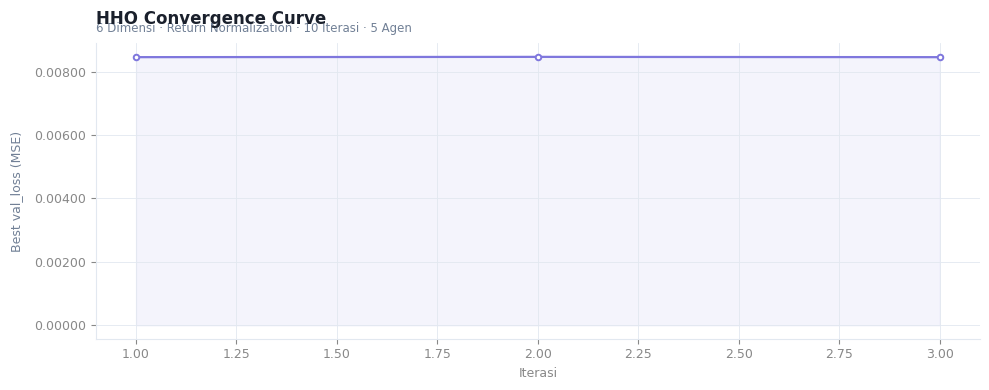

In [ ]:
fig4, ax4 = plt.subplots(figsize=(10, 4))
fig4.subplots_adjust(top=0.86, bottom=0.12, left=0.10, right=0.97)

iters = range(1, len(best_convergence) + 1)
ax4.plot(iters, best_convergence,
         color=_C['hho_cv'], lw=1.6, marker='o', markersize=4,
         markerfacecolor='white', markeredgecolor=_C['hho_cv'], markeredgewidth=1.4)
ax4.fill_between(iters, best_convergence, alpha=0.08, color=_C['hho_cv'])

_spine(ax4)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.5f}'))
ax4.set_ylabel('Best val_loss (MSE)', fontsize=9, color='#718096', labelpad=8)
ax4.set_xlabel('Iterasi', fontsize=9, color='#888888')
ax4.set_title('HHO Convergence Curve(NASDAQ)',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax4, f'6 Dimensi · Return Normalization · {Max_iter} Iterasi · {SearchAgents_no} Agen')
plt.tight_layout(); plt.show()


## 19. PLOT - HHO Operations per Run

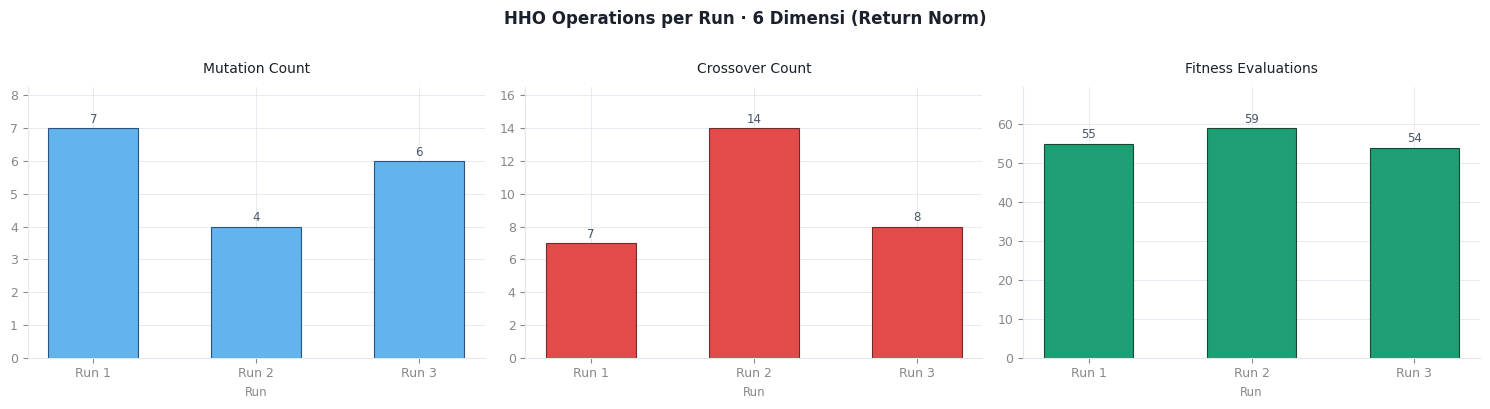

In [ ]:
runs_x = list(range(1, num_runs + 1))
fig5, axes5 = plt.subplots(1, 3, figsize=(15, 4))
fig5.subplots_adjust(top=0.84, bottom=0.12, left=0.06, right=0.98, wspace=0.32)

bar_cfg = [
    (mutation_counts,     _C['val_act'], '#2C5282', 'Mutation Count'),
    (crossover_counts,    _C['test_p'],  '#742A2A', 'Crossover Count'),
    (fitness_evaluations, _C['split'],   '#1A4731', 'Fitness Evaluations'),
]
for ax_i, (vals, fc, ec, ttl) in zip(axes5, bar_cfg):
    bars = ax_i.bar(runs_x, vals, color=fc, edgecolor=ec,
                    linewidth=0.8, width=0.55, zorder=2)
    for bar, val in zip(bars, vals):
        ax_i.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + max(vals) * 0.01,
                  str(int(val)), ha='center', va='bottom',
                  fontsize=8.5, color='#4A5568', fontweight='500')
    _spine(ax_i)
    ax_i.set_title(ttl, fontsize=10, fontweight='500', color='#1A202C', pad=10)
    ax_i.set_xlabel('Run', fontsize=8.5, color='#888888')
    ax_i.set_xticks(runs_x)
    ax_i.set_xticklabels([f'Run {r}' for r in runs_x])
    ax_i.set_ylim(0, max(vals) * 1.18)

fig5.suptitle('HHO Operations per Run · 6 Dimensi (Return Norm) - NASDAQ',
              fontsize=12, fontweight='bold', color='#1A202C', y=1.01)
plt.tight_layout(); plt.show()


## 20. PLOT - Distribution of Fitness Values

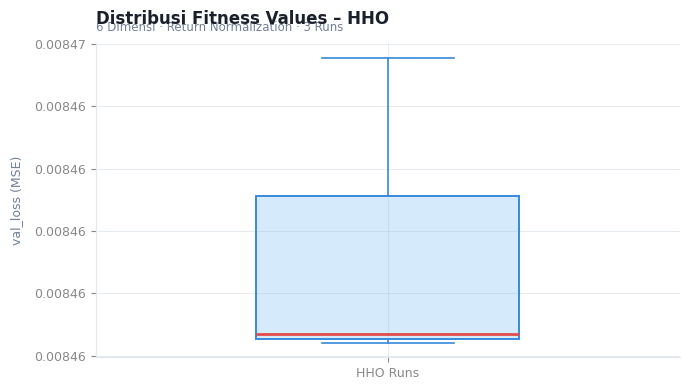

In [30]:
fig6, ax6 = plt.subplots(figsize=(7, 4))
fig6.subplots_adjust(top=0.86, bottom=0.12, left=0.14, right=0.97)

ax6.boxplot(fitness_values, patch_artist=True, widths=0.45,
            boxprops=dict(facecolor=_C['val_act'] + '44',
                          color=_C['act'], linewidth=1.4),
            medianprops=dict(color=_C['test_p'], linewidth=2),
            whiskerprops=dict(color=_C['act'], linewidth=1.2),
            capprops=dict(color=_C['act'], linewidth=1.2),
            flierprops=dict(marker='o', color=_C['test_p'],
                            markerfacecolor=_C['test_p'], markersize=5))

_spine(ax6)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.5f}'))
ax6.set_ylabel('val_loss (MSE)', fontsize=9, color='#718096', labelpad=8)
ax6.set_xticks([1]); ax6.set_xticklabels(['HHO Runs'])
ax6.set_title('Distribusi Fitness Values – HHO',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax6, f'6 Dimensi · Return Normalization · {num_runs} Runs')
plt.tight_layout(); plt.show()


## 21. TABEL RINGKASAN EVALUASI

In [ ]:
print("\n" + "="*75)
print("  RINGKASAN EVALUASI - LSTM MIMO + HHO (Min-Max Normalization)")
print("="*75)
print(f"  {'Set':<8} {'Horizon':<14} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
print(f"  {'-'*54}")

for label, y_true_abs, y_pred_abs in [
    ("TRAIN", y_train_abs, train_predict),
    ("VAL",   y_val_abs,   val_predict),
    ("TEST",  y_test_abs,  test_predict),
]:
    for i in range(n_forecast):
        _, rmse, mae, mape = evaluate(y_true_abs[:, i], y_pred_abs[:, i])
        h = f"t+{i+1} (Hari ke-{i+1})"
        print(f"  {label:<8} {h:<14} {rmse:>10.4f} {mae:>10.4f} {mape:>9.2f}%")
    _, rmse_a, mae_a, mape_a = evaluate(y_true_abs.flatten(), y_pred_abs.flatten())
    print(f"  {label:<8} {'Average':<14} {rmse_a:>10.4f} {mae_a:>10.4f} {mape_a:>9.2f}%")
    print(f"  {'-'*54}")


## 22. SIMPAN MODEL & METADATA

In [ ]:
import json, os

os.makedirs('models', exist_ok=True)
best_model.save('models/lstm_mimo_hho.h5')

metadata = {
    "model_name": "LSTM MIMO + HHO",
    "n_input": n_input,
    "n_forecast": n_forecast,
    "features": TARGET_COLS,
    "hyperparameters": {
        "units_1": best_units1,
        "units_2": best_units2,
        "dropout_rate_1": best_drop1,
        "dropout_rate_2": best_drop2,
        "learning_rate": best_lr,
        "batch_size": best_bs
    },
    "hho_search": {
        "dimensions": dim,
        "lower_bound": lb.tolist(),
        "upper_bound": ub.tolist(),
        "search_agents": SearchAgents_no,
        "max_iter": Max_iter,
        "num_runs": num_runs,
        "best_val_loss": float(best_overall_fitness)
    },
    "normalization": "MinMaxScaler per-fitur pada harga OHLCV absolut (fit pada train only)",
    "split": "70/15/15 (walk-forward, time-ordered)"
}
with open('models/lstm_mimo_hho_meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model dan metadata LSTM MIMO + HHO tersimpan di folder 'models/'.")
